<a href="https://colab.research.google.com/github/The-MasterMind7/FeelReal.AI/blob/main/FEELREAL_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Comparison and Hashtagging System

## Core Utilities and Setup

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import cv2
from google.colab import files

In [ ]:
# Helper function to create a dummy image for demonstration
def create_dummy_image(filepath='dummy_image.png', size=(200, 200), color=(100, 150, 200)):
    image = Image.new('RGB', size, color)
    image.save(filepath)
    print(f"Dummy image created at {filepath}")
    return filepath

## Image Preprocessing

In [ ]:
def preprocess_image(image_path, target_size=(128, 128), grayscale=True, preserve_aspect_ratio=True):
    """
    Loads an image, resizes it, converts it to grayscale (optional), and normalizes pixel values.

    Args:
        image_path (str): Path to the image file.
        target_size (tuple): Desired (width, height) of the output image.
        grayscale (bool): Whether to convert the image to grayscale.
        preserve_aspect_ratio (bool): If True, resizes the image to fit within
                                      target_size while maintaining its aspect ratio.
                                      If False, resizes directly to target_size,
                                      potentially distorting the image.

    Returns:
        numpy.ndarray: The preprocessed image as a numpy array with pixel values normalized to [0, 1].
    """
    try:
        img = Image.open(image_path)

        if preserve_aspect_ratio:
            # Use thumbnail to resize the image to fit within target_size while preserving aspect ratio.
            # This modifies the image in place and ensures no distortion.
            img.thumbnail(target_size, Image.LANCZOS)
        else:
            img = img.resize(target_size, Image.LANCZOS)

        if grayscale:
            img = img.convert('L') # Convert to grayscale

        img_array = np.array(img)

        # Normalize pixel values to [0, 1]
        img_array = img_array / 255.0

        return img_array
    except FileNotFoundError:
        print(f"Error: Image not found at {image_path}")
        return None
    except Exception as e:
        print(f"An error occurred during image preprocessing: {e}")
        return None

Dummy image created at dummy_image.png
Original image size: (200, 200)
Preprocessed image shape: (200, 200)
Preprocessed image pixel value range: [0.5529411764705883, 0.5529411764705883]


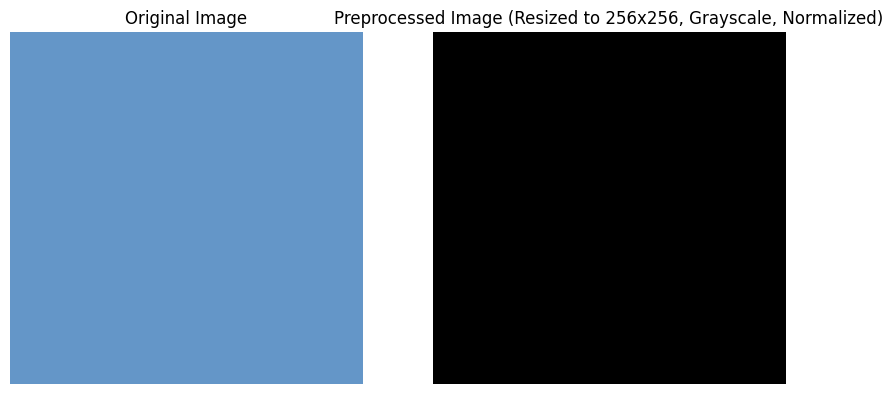

Cleaned up dummy image at dummy_image.png


In [ ]:
# Demonstrate preprocessing with a dummy image
dummy_image_path = create_dummy_image()
original_img = Image.open(dummy_image_path)
preprocessed_img_array = preprocess_image(dummy_image_path, target_size=(256, 256)) # Increased target_size

if preprocessed_img_array is not None:
    print(f"Original image size: {original_img.size}")
    print(f"Preprocessed image shape: {preprocessed_img_array.shape}")
    print(f"Preprocessed image pixel value range: [{preprocessed_img_array.min()}, {preprocessed_img_array.max()}]")

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    # For grayscale images, imshow needs cmap='gray'
    if preprocessed_img_array.ndim == 2: # Check if it's a 2D grayscale image
        plt.imshow(preprocessed_img_array, cmap='gray')
    else:
        plt.imshow(preprocessed_img_array)
    plt.title('Preprocessed Image (Resized to 256x256, Grayscale, Normalized)') # Updated title
    plt.axis('off')

    plt.show()

    # Clean up the dummy image
    os.remove(dummy_image_path)
    print(f"Cleaned up dummy image at {dummy_image_path}")

## Local Image Hashtag Database

In [ ]:
# Initialize or clear the local image-hashtag database
image_hashtag_database = {}
print("Local image hashtag database initialized/cleared.")

def add_image_to_database(image_path, hashtags):
    """
    Adds an image path and its associated hashtags to the global database.
    Hashtags will be stored in lowercase for case-insensitive matching.
    """
    global image_hashtag_database
    image_hashtag_database[image_path] = [tag.lower() for tag in hashtags]
    print(f"Added '{image_path}' to database with hashtags: {hashtags}")

def find_matching_images_by_hashtags(query_hashtags, database, min_overlap=1):
    """
    Finds images in the database that share common hashtags with the query hashtags.

    Args:
        query_hashtags (list): A list of hashtags for the query image.
        database (dict): The image-hashtag database.
        min_overlap (int): The minimum number of shared hashtags required for a match.

    Returns:
        list: A list of tuples (image_path, shared_hashtags_count) for matching images.
    """
    query_hashtags_lower = [tag.lower() for tag in query_hashtags]
    matches = []

    for img_path, db_hashtags in database.items():
        shared_hashtags = set(query_hashtags_lower).intersection(set(db_hashtags))
        if len(shared_hashtags) >= min_overlap:
            matches.append((img_path, len(shared_hashtags)))

    # Sort matches by the number of shared hashtags (most common first)
    matches.sort(key=lambda x: x[1], reverse=True)
    return matches

Local image hashtag database initialized/cleared.


In [ ]:
image_to_remove = 'fake stanley.jpg'

# Remove from file system if it exists
if os.path.exists(image_to_remove):
    os.remove(image_to_remove)
    print(f"Removed '{image_to_remove}' from file system.")
else:
    print(f"'{image_to_remove}' not found on file system, no action taken.")

# Remove from image_hashtag_database if it exists
if image_to_remove in image_hashtag_database:
    del image_hashtag_database[image_to_remove]
    print(f"Removed '{image_to_remove}' from image_hashtag_database.")
else:
    print(f"'{image_to_remove}' not found in image_hashtag_database, no action taken.")

print("Current image hashtag database after removal:")
for img, tags in image_hashtag_database.items():
    print(f"  {img}: {tags}")

Removed 'fake stanley.jpg' from file system.
Removed 'fake stanley.jpg' from image_hashtag_database.
Current image hashtag database after removal:
  Copilot_20260502_180638 (3).png: ['stanley cup', 'metal', 'drinkware']
  stanley (1).png: ['stanley cup']
  Copilot_20260502_180638 (4).png: ['stanley cup', 'metal', 'drinkware']


## User Workflow: Upload Query Image

Please upload your query image (e.g., 'fake stanley.jpg') now:


Saving stanley.png to stanley (1).png
File 'stanley (1).png' uploaded successfully.

Original uploaded image size: (337, 777)
Preprocessed uploaded image shape: (512, 222)


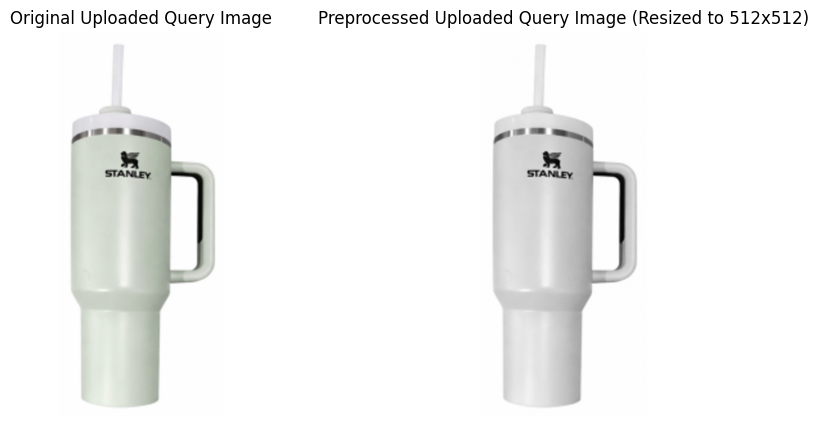

In [ ]:
# Prompt the user to upload a file for the query image
print("Please upload your query image (e.g., 'fake stanley.jpg') now:")
uploaded_files = files.upload()

uploaded_image_path = None
if uploaded_files:
    uploaded_image_filename = list(uploaded_files.keys())[0]
    uploaded_image_path = uploaded_image_filename
    print(f"File '{uploaded_image_filename}' uploaded successfully.")

    # Preprocess and display the uploaded image for verification
    try:
        original_uploaded_img = Image.open(uploaded_image_path)
        preprocessed_uploaded_img_array = preprocess_image(uploaded_image_path, target_size=(512,512)) # Increased target_size

        if preprocessed_uploaded_img_array is not None:
            print(f"\nOriginal uploaded image size: {original_uploaded_img.size}")
            print(f"Preprocessed uploaded image shape: {preprocessed_uploaded_img_array.shape}")

            plt.figure(figsize=(10, 5))

            plt.subplot(1, 2, 1)
            plt.imshow(original_uploaded_img)
            plt.title('Original Uploaded Query Image')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            if preprocessed_uploaded_img_array.ndim == 2:
                plt.imshow(preprocessed_uploaded_img_array, cmap='gray')
            else:
                plt.imshow(preprocessed_uploaded_img_array)
            plt.title('Preprocessed Uploaded Query Image (Resized to 512x512)')
            plt.axis('off')

            plt.show()
    except Exception as e:
        print(f"Error processing uploaded image: {e}")
else:
    print("No query image was uploaded.")

### Add Query Image to Database

In [ ]:
if uploaded_image_path and os.path.exists(uploaded_image_path):
    print(f"Adding '{uploaded_image_path}' to the database.")
    # Prompt user for hashtags
    hashtags_input = input("Enter hashtags for this query image (comma-separated, e.g., 'nature, tree, green'): ")
    user_hashtags = [tag.strip() for tag in hashtags_input.split(',') if tag.strip()]

    if user_hashtags:
        add_image_to_database(uploaded_image_path, user_hashtags)
    else:
        print("No hashtags entered for the uploaded query image.")
else:
    print("No uploaded query image available to add to the database. Please run the image upload cell first.")

Adding 'stanley (1).png' to the database.
Enter hashtags for this query image (comma-separated, e.g., 'nature, tree, green'): stanley cup
Added 'stanley (1).png' to database with hashtags: ['stanley cup']


## User Workflow: Upload Database Reference Image

In [ ]:
print("Please upload your reference image (e.g., 'real_stanley.webp') now:")
uploaded_real_stanley_files = files.upload()

new_real_stanley_path = None
if uploaded_real_stanley_files:
    new_real_stanley_filename = list(uploaded_real_stanley_files.keys())[0]
    new_real_stanley_path = new_real_stanley_filename
    print(f"File '{new_real_stanley_filename}' uploaded successfully.")
    print(f"You can now use '{new_real_stanley_path}' as your database image path for comparison.")

    # Add this reference image to the hashtag database as well
    ref_hashtags_input = input(f"Enter hashtags for '{new_real_stanley_path}' (comma-separated, e.g., 'stanley cup, metal, drinkware'): ")
    ref_user_hashtags = [tag.strip() for tag in ref_hashtags_input.split(',') if tag.strip()]
    if ref_user_hashtags:
        add_image_to_database(new_real_stanley_path, ref_user_hashtags)
    else:
        print("No hashtags entered for the reference image.")
else:
    print("No reference image was uploaded.")

Please upload your reference image (e.g., 'real_stanley.webp') now:


Saving Copilot_20260502_180638.png to Copilot_20260502_180638 (4).png
File 'Copilot_20260502_180638 (4).png' uploaded successfully.
You can now use 'Copilot_20260502_180638 (4).png' as your database image path for comparison.
Enter hashtags for 'Copilot_20260502_180638 (4).png' (comma-separated, e.g., 'stanley cup, metal, drinkware'): stanley cup, metal, drinkware
Added 'Copilot_20260502_180638 (4).png' to database with hashtags: ['stanley cup', 'metal', 'drinkware']


### Subtask: Demonstrate Hashtag-Based Matching (using current database)


--- Demonstrating Image Matching Based on Hashtags ---
Query image: 'stanley (1).png' with hashtags: ['stanley cup']

Current Database Content:
  fake stanley.jpg: ['stanley cup']
  Copilot_20260502_180638 (3).png: ['stanley cup', 'metal', 'drinkware']
  stanley (1).png: ['stanley cup']
  Copilot_20260502_180638 (4).png: ['stanley cup', 'metal', 'drinkware']

Matching Images Found:
- 'fake stanley.jpg' (Shared hashtags: 1)


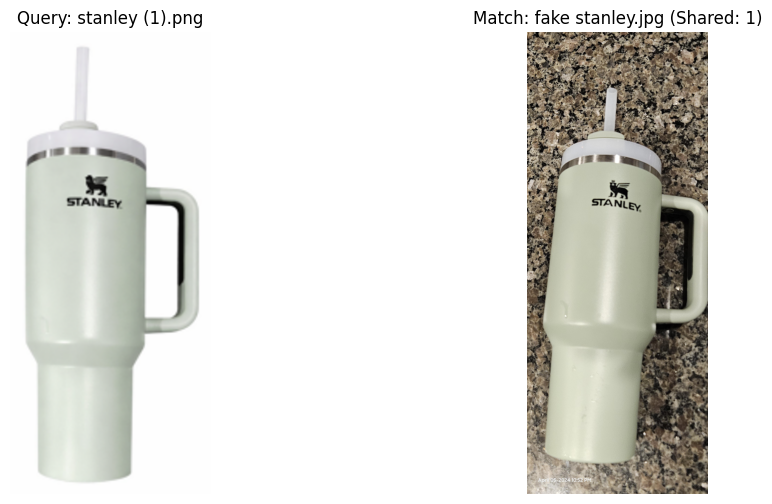

- 'Copilot_20260502_180638 (3).png' (Shared hashtags: 1)


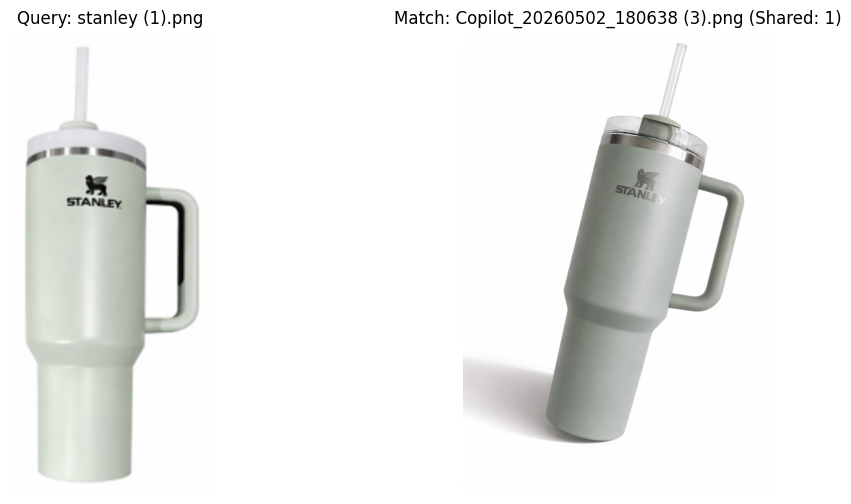

- 'Copilot_20260502_180638 (4).png' (Shared hashtags: 1)


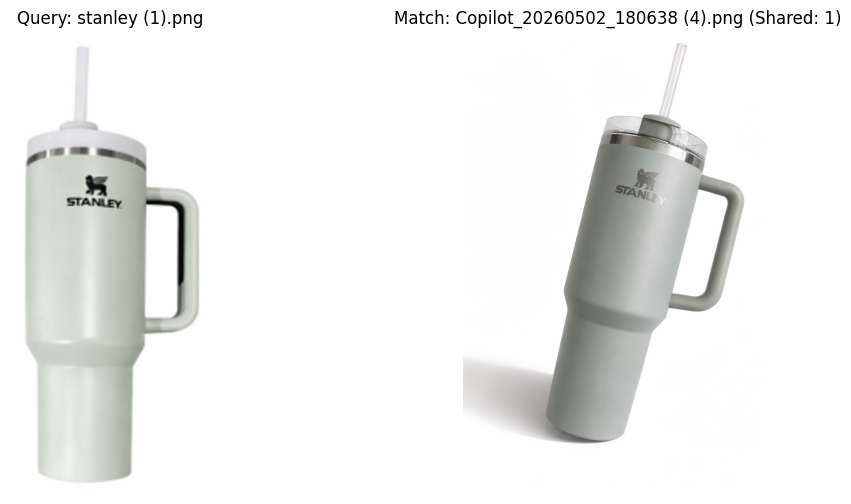

In [ ]:
if uploaded_image_path and uploaded_image_path in image_hashtag_database:
    print("\n--- Demonstrating Image Matching Based on Hashtags ---")
    query_img_hashtags = image_hashtag_database[uploaded_image_path]
    print(f"Query image: '{uploaded_image_path}' with hashtags: {query_img_hashtags}")

    print("\nCurrent Database Content:")
    for img, tags in image_hashtag_database.items():
        print(f"  {img}: {tags}")

    found_matches = find_matching_images_by_hashtags(query_img_hashtags, image_hashtag_database, min_overlap=1)

    if found_matches:
        print("\nMatching Images Found:")
        query_original_img = Image.open(uploaded_image_path) # Load query image once

        for match_path, num_shared_tags in found_matches:
            if match_path == uploaded_image_path: # Exclude self-match from being listed as a 'match'
                continue

            print(f"- '{match_path}' (Shared hashtags: {num_shared_tags})")

            # Load the matched image
            matched_original_img = Image.open(match_path)

            plt.figure(figsize=(12, 6))

            plt.subplot(1, 2, 1)
            plt.imshow(query_original_img)
            plt.title(f"Query: {os.path.basename(uploaded_image_path)}")
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(matched_original_img)
            plt.title(f"Match: {os.path.basename(match_path)} (Shared: {num_shared_tags})")
            plt.axis('off')

            plt.show()
    else:
        print("\nNo matching images found in the database.")
else:
    print("Cannot demonstrate matching: Query image not in database or not available.")

## Advanced Image Comparison (Feature-Based)

### Subtask: Load and Preprocess Images for Comparison

### Subtask: Load and Preprocess Images for Comparison (with Background Removal)

Query image path: stanley (1).png
Database image path: Copilot_20260502_180638 (4).png
Query image PIL object created from: stanley (1).png
Query image preprocessed.
Database image PIL object created from: Copilot_20260502_180638 (4).png
Database image preprocessed.
Shape of preprocessed query image: (512, 222)
Shape of preprocessed database image: (512, 341)


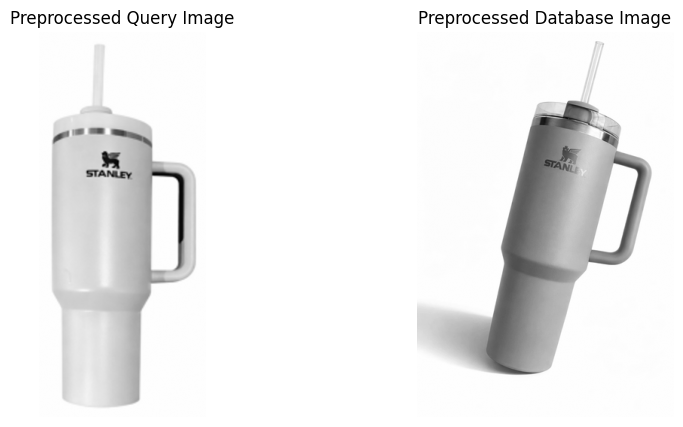

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# 1. Define the file paths for the query image and the database image
# These variables should be set from the upload cells above.
query_image_filepath = uploaded_image_path
database_image_filepath = new_real_stanley_path

print(f"Query image path: {query_image_filepath}")
print(f"Database image path: {database_image_filepath}")

# Check if paths are valid
if not query_image_filepath or not os.path.exists(query_image_filepath):
    print(f"Error: Query image not found at {query_image_filepath}")
    query_image_pil = None
    preprocessed_query_image = None
else:
    query_image_pil = Image.open(query_image_filepath)
    print(f"Query image PIL object created from: {query_image_filepath}")
    preprocessed_query_image = preprocess_image(query_image_filepath, target_size=(512, 512))
    print(f"Query image preprocessed.")

if not database_image_filepath or not os.path.exists(database_image_filepath):
    print(f"Error: Database image not found at {database_image_filepath}")
    database_image_pil = None
    preprocessed_database_image = None
else:
    database_image_pil = Image.open(database_image_filepath)
    print(f"Database image PIL object created from: {database_image_filepath}")
    preprocessed_database_image = preprocess_image(database_image_filepath, target_size=(512, 512))
    print(f"Database image preprocessed.")


# 6. Print the shapes of both preprocessed_query_image and preprocessed_database_image
if preprocessed_query_image is not None and preprocessed_database_image is not None:
    print(f"Shape of preprocessed query image: {preprocessed_query_image.shape}")
    print(f"Shape of preprocessed database image: {preprocessed_database_image.shape}")
else:
    print("Error: One or both images could not be preprocessed or found.")

# Display the preprocessed images to visually confirm
if preprocessed_query_image is not None and preprocessed_database_image is not None:
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    if preprocessed_query_image.ndim == 2:
        plt.imshow(preprocessed_query_image, cmap='gray')
    else:
        plt.imshow(preprocessed_query_image)
    plt.title('Preprocessed Query Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    if preprocessed_database_image.ndim == 2:
        plt.imshow(preprocessed_database_image, cmap='gray')
    else:
        plt.imshow(preprocessed_database_image)
    plt.title('Preprocessed Database Image')
    plt.axis('off')

    plt.show()

Query image re-preprocessed using original file: stanley (1).png
Database image re-preprocessed using original file: Copilot_20260502_180638 (4).png


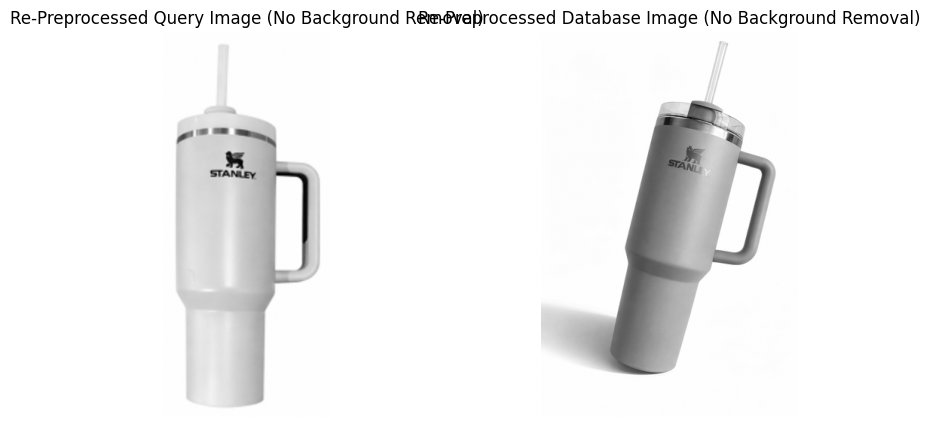

In [ ]:
# Re-establishing preprocessed images without background removal
# These filepaths refer to the *original* uploaded images, not the background-removed ones.
query_image_filepath_original = uploaded_image_path
database_image_filepath_original = new_real_stanley_path

if not query_image_filepath_original or not os.path.exists(query_image_filepath_original):
    print(f"Error: Original query image not found at {query_image_filepath_original}")
    preprocessed_query_image = None
else:
    preprocessed_query_image = preprocess_image(query_image_filepath_original, target_size=(512, 512))
    print(f"Query image re-preprocessed using original file: {query_image_filepath_original}")

if not database_image_filepath_original or not os.path.exists(database_image_filepath_original):
    print(f"Error: Original database image not found at {database_image_filepath_original}")
    preprocessed_database_image = None
else:
    preprocessed_database_image = preprocess_image(database_image_filepath_original, target_size=(512, 512))
    print(f"Database image re-preprocessed using original file: {database_image_filepath_original}")

# Display the re-preprocessed images to visually confirm
if preprocessed_query_image is not None and preprocessed_database_image is not None:
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    if preprocessed_query_image.ndim == 2:
        plt.imshow(preprocessed_query_image, cmap='gray')
    else:
        plt.imshow(preprocessed_query_image)
    plt.title('Re-Preprocessed Query Image (No Background Removal)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    if preprocessed_database_image.ndim == 2:
        plt.imshow(preprocessed_database_image, cmap='gray')
    else:
        plt.imshow(preprocessed_database_image)
    plt.title('Re-Preprocessed Database Image (No Background Removal)')
    plt.axis('off')

    plt.show()

### Subtask: Feature Detection and Description (ORB)

In [ ]:
import cv2

print("Progress: Initializing AKAZE feature detector...")

# Ensure the preprocessed images are not None before proceeding
if preprocessed_query_image is None or preprocessed_database_image is None:
    raise ValueError("Preprocessed images are not available. Please ensure previous steps ran successfully.")

# --- Debugging: Print actual shapes at the start of this cell ---
print(f"DEBUG: Shape of preprocessed_query_image received by AKAZE cell: {preprocessed_query_image.shape}")
print(f"DEBUG: Shape of preprocessed_database_image received by AKAZE cell: {preprocessed_database_image.shape}")

# 1. Convert preprocessed images to uint8, if they are not already
# The preprocessed images are normalized to [0, 1], so we need to scale back to [0, 255]
# and convert to unsigned 8-bit integer for OpenCV.

# Check if images are already uint8, otherwise convert
# If they are float, convert to uint8 by scaling
if preprocessed_query_image.dtype != np.uint8:
    query_image_uint8 = (preprocessed_query_image * 255).astype(np.uint8)
else:
    query_image_uint8 = preprocessed_query_image

if preprocessed_database_image.dtype != np.uint8:
    database_image_uint8 = (preprocessed_database_image * 255).astype(np.uint8)
else:
    database_image_uint8 = preprocessed_database_image


print(f"Query image shape after uint8 conversion: {query_image_uint8.shape}, dtype: {query_image_uint8.dtype}")
print(f"Database image shape after uint8 conversion: {database_image_uint8.shape}, dtype: {database_image_uint8.dtype}")

# 2. Initialize the AKAZE detector
akaze = cv2.AKAZE_create()

# 3. Detect keypoints and compute descriptors for the query image
print("Progress: Detecting keypoints and computing descriptors for query image...")
kp1, des1 = akaze.detectAndCompute(query_image_uint8, None)

# 4. Detect keypoints and compute descriptors for the database image
print("Progress: Detecting keypoints and computing descriptors for database image...")
kp2, des2 = akaze.detectAndCompute(database_image_uint8, None)

print("Feature detection and description complete.")

# 5. Print the number of keypoints found for both images
if kp1 is not None:
    print(f"Number of keypoints found in query image: {len(kp1)}")
else:
    print("No keypoints found in query image.")

if kp2 is not None:
    print(f"Number of keypoints found in database image: {len(kp2)}")
else:
    print("No keypoints found in database image.")

# 6. Print the shape of the descriptors for both images
if des1 is not None:
    print(f"Shape of descriptors for query image: {des1.shape}")
else:
    print("No descriptors found for query image.")

if des2 is not None:
    print(f"Shape of descriptors for database image: {des2.shape}")
else:
    print("No descriptors found for database image.")

Progress: Initializing AKAZE feature detector...
DEBUG: Shape of preprocessed_query_image received by AKAZE cell: (512, 222)
DEBUG: Shape of preprocessed_database_image received by AKAZE cell: (512, 341)
Query image shape after uint8 conversion: (512, 222), dtype: uint8
Database image shape after uint8 conversion: (512, 341), dtype: uint8
Progress: Detecting keypoints and computing descriptors for query image...
Progress: Detecting keypoints and computing descriptors for database image...
Feature detection and description complete.
Number of keypoints found in query image: 89
Number of keypoints found in database image: 91
Shape of descriptors for query image: (89, 61)
Shape of descriptors for database image: (91, 61)


### Subtask: Feature Matching (BFMatcher with Ratio Test)

**Reasoning for Adjustment:**
The previous homography estimation was inaccurate due to a very low number of 'good matches' (only 3 were found). A more robust homography requires a larger set of reliable correspondences between the two images.

To address this, we will temporarily adjust the `ratiotest_threshold` in the `cv2.BFMatcher` step. This parameter controls how strictly matches are filtered: a lower value means only very strong matches pass, while a higher threshold (closer to 1.0) will allow more matches, potentially including some weaker but still valid ones.

Initially, we increased the threshold to get more matches. However, the resulting alignment was worse, indicating that many of these additional matches were incorrect (outliers). For homography estimation, a smaller number of *highly accurate* matches is preferable to a larger number of mixed-quality matches, as the RANSAC algorithm can still be overwhelmed by too many strong outliers.

Therefore, we are now making the `ratiotest_threshold` stricter again (reducing it to 0.75). This aims to filter out the less reliable correspondences, providing a cleaner set of inliers for the RANSAC algorithm during homography estimation. While this might reduce the total count of 'good matches', the expectation is that their quality will be significantly higher, leading to a more robust and accurate image alignment.

In [ ]:
import cv2
import numpy as np

print("Progress: Initializing SIFT feature detector...")

# Ensure the preprocessed images are not None before proceeding
if preprocessed_query_image is None or preprocessed_database_image is None:
    raise ValueError("Preprocessed images are not available. Please ensure previous steps ran successfully.")

# --- Debugging: Print actual shapes at the start of this cell ---
print(f"DEBUG: Shape of preprocessed_query_image received by SIFT cell: {preprocessed_query_image.shape}")
print(f"DEBUG: Shape of preprocessed_database_image received by SIFT cell: {preprocessed_database_image.shape}")

# 1. Convert preprocessed images to uint8, if they are not already
# The preprocessed images are normalized to [0, 1], so we need to scale back to [0, 255]
# and convert to unsigned 8-bit integer for OpenCV.

# Check if images are already uint8, otherwise convert
# If they are float, convert to uint8 by scaling
if preprocessed_query_image.dtype != np.uint8:
    query_image_uint8 = (preprocessed_query_image * 255).astype(np.uint8)
else:
    query_image_uint8 = preprocessed_query_image

if preprocessed_database_image.dtype != np.uint8:
    database_image_uint8 = (preprocessed_database_image * 255).astype(np.uint8)
else:
    database_image_uint8 = preprocessed_database_image


print(f"Query image shape after uint8 conversion: {query_image_uint8.shape}, dtype: {query_image_uint8.dtype}")
print(f"Database image shape after uint8 conversion: {database_image_uint8.shape}, dtype: {database_image_uint8.dtype}")

# 2. Initialize the SIFT detector
sift = cv2.SIFT_create()

# 3. Detect keypoints and compute descriptors for the query image
print("Progress: Detecting keypoints and computing descriptors for query image...")
kp1, des1 = sift.detectAndCompute(query_image_uint8, None)

# 4. Detect keypoints and compute descriptors for the database image
print("Progress: Detecting keypoints and computing descriptors for database image...")
kp2, des2 = sift.detectAndCompute(database_image_uint8, None)

print("Feature detection and description complete.")

# 5. Print the number of keypoints found for both images
if kp1 is not None:
    print(f"Number of keypoints found in query image: {len(kp1)}")
else:
    print("No keypoints found in query image.")

if kp2 is not None:
    print(f"Number of keypoints found in database image: {len(kp2)}")
else:
    print("No keypoints found in database image.")

# 6. Print the shape of the descriptors for both images
if des1 is not None:
    print(f"Shape of descriptors for query image: {des1.shape}")
else:
    print("No descriptors found for query image.")

if des2 is not None:
    print(f"Shape of descriptors for database image: {des2.shape}")
else:
    print("No descriptors found for database image.")

Progress: Initializing SIFT feature detector...
DEBUG: Shape of preprocessed_query_image received by SIFT cell: (512, 222)
DEBUG: Shape of preprocessed_database_image received by SIFT cell: (512, 341)
Query image shape after uint8 conversion: (512, 222), dtype: uint8
Database image shape after uint8 conversion: (512, 341), dtype: uint8
Progress: Detecting keypoints and computing descriptors for query image...
Progress: Detecting keypoints and computing descriptors for database image...
Feature detection and description complete.
Number of keypoints found in query image: 115
Number of keypoints found in database image: 99
Shape of descriptors for query image: (115, 128)
Shape of descriptors for database image: (99, 128)


Progress: Performing feature matching...
Number of raw matches: 115
Number of good matches after ratio test: 11


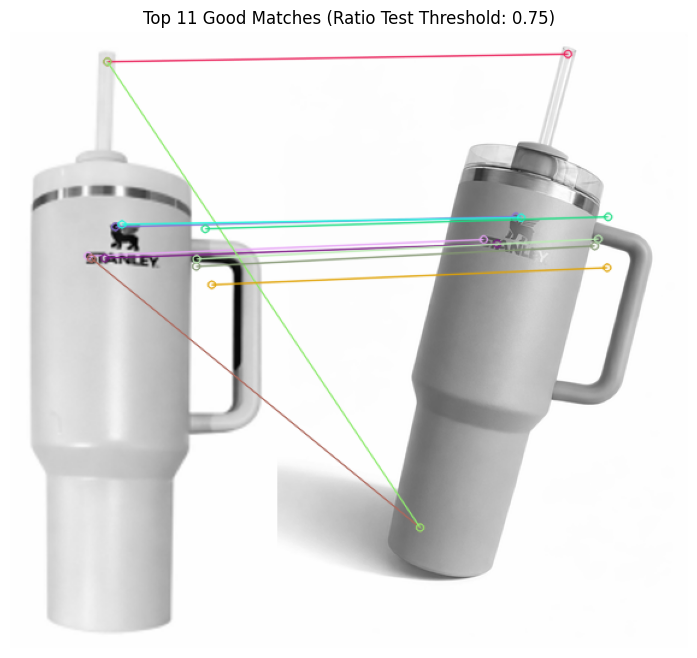

Feature matching complete.


In [ ]:
import cv2
import matplotlib.pyplot as plt

print("Progress: Performing feature matching...")

# Ensure descriptors exist from the previous step
if des1 is None or des2 is None:
    raise ValueError("Descriptors are not available. Please ensure previous feature detection ran successfully.")

# 1. Initialize the Brute-Force Matcher
# For SIFT, use NORM_L2 distance as it uses float descriptors.
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False) # Changed to NORM_L2 for SIFT descriptors

# 2. Perform k-NN matching
# Use k=2 for Lowe's Ratio Test (finds the two best matches for each descriptor)
matches = bf.knnMatch(des1, des2, k=2)

# 3. Apply Lowe's Ratio Test to filter good matches
good_matches = []
# The ratio test threshold can be adjusted. A lower value means stricter matching.
ratiotest_threshold = 0.75 # Default threshold, can be tuned

for m, n in matches:
    if m.distance < ratiotest_threshold * n.distance:
        good_matches.append(m)

print(f"Number of raw matches: {len(matches)}")
print(f"Number of good matches after ratio test: {len(good_matches)}")

# 4. Draw the top N matches (optional, for visualization)
# Adjust max_matches_to_draw as needed
max_matches_to_draw = 100

# To draw matches, we need the original uint8 images used for feature detection
# These were created in the previous cell

# Check if images are available and display matches
if 'query_image_uint8' in locals() and 'database_image_uint8' in locals():
    # Only draw if there are good matches
    if good_matches:
        # Ensure we don't try to draw more matches than exist
        draw_matches = good_matches[:min(len(good_matches), max_matches_to_draw)]

        # Draw matches. The query_image_uint8 and database_image_uint8 should be in grayscale (1 channel)
        # If they were RGB, we'd need to convert back to grayscale before passing to drawMatches.
        # Since our preprocess_image returns grayscale, this should be fine.
        img_matches = cv2.drawMatches(
            query_image_uint8, kp1,
            database_image_uint8, kp2,
            draw_matches, None,
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )

        plt.figure(figsize=(15, 8))
        plt.imshow(img_matches)
        plt.title(f'Top {len(draw_matches)} Good Matches (Ratio Test Threshold: {ratiotest_threshold})')
        plt.axis('off')
        plt.show()
    else:
        print("No good matches to draw.")
else:
    print("Original uint8 images not found for drawing matches. Skipping visualization.")

print("Feature matching complete.")

### Subtask: Estimate Homography and Align Images

Progress: Estimating homography and aligning images...
Homography estimated and query image aligned.


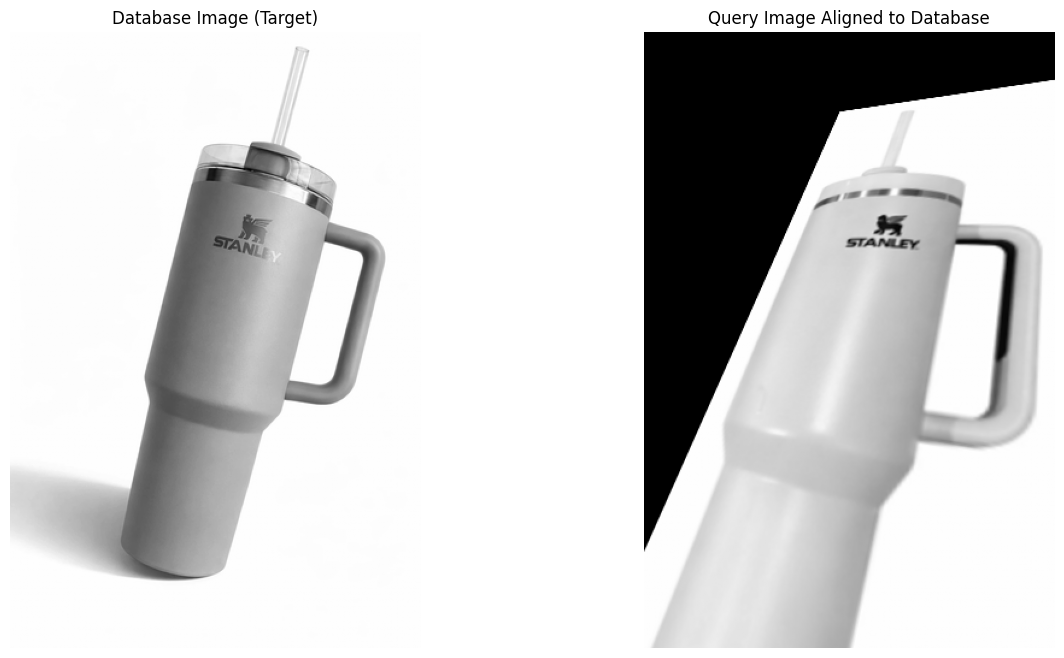

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Progress: Estimating homography and aligning images...")

# Ensure good_matches exist
if not good_matches:
    raise ValueError("No good matches found. Cannot estimate homography.")

# 1. Extract matched keypoints
# query_image_uint8 keypoints are kp1, database_image_uint8 keypoints are kp2
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# 2. Find the Homography matrix
# RANSAC is robust to outliers
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

if M is None:
    raise ValueError("Homography estimation failed. Not enough inliers.")

# Get the height and width of the database image (target for alignment)
h, w = database_image_uint8.shape[:2]

# 3. Warp the query image to align with the database image
aligned_query_image = cv2.warpPerspective(query_image_uint8, M, (w, h))

print("Homography estimated and query image aligned.")

# 4. Visualize the aligned images
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.imshow(database_image_uint8, cmap='gray')
plt.title('Database Image (Target)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(aligned_query_image, cmap='gray')
plt.title('Query Image Aligned to Database')
plt.axis('off')

plt.show()

### Subtask: Analyze Differences

### Subtask: Define Similarity Metric (e.g., SSIM)

Progress: Analyzing differences between aligned images...
Difference analysis complete.


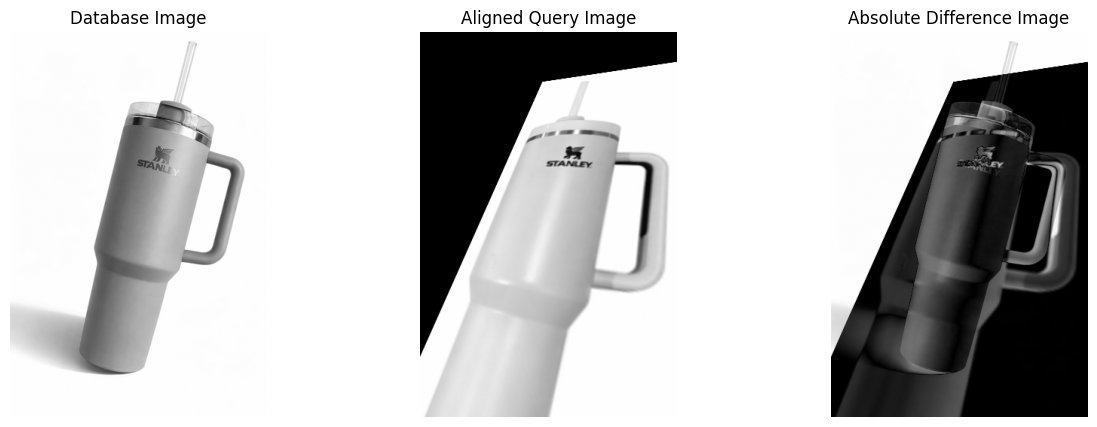

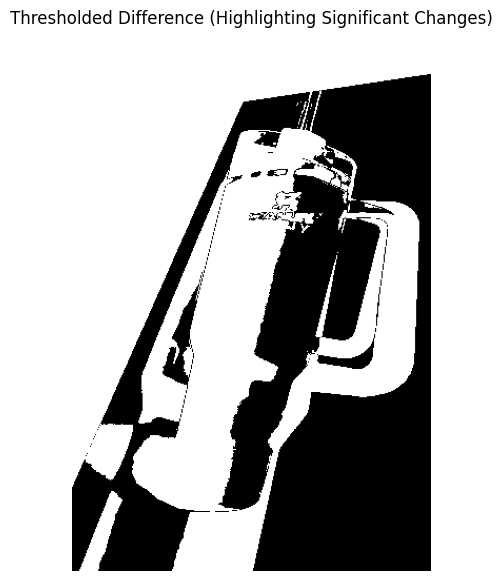

In [ ]:
 vbimport cv2
import numpy as np
import matplotlib.pyplot as plt

print("Progress: Analyzing differences between aligned images...")

# Ensure both images are available
if aligned_query_image is None or database_image_uint8 is None:
    raise ValueError("Aligned query image or database image not available for difference analysis.")

# Calculate the absolute difference between the aligned query image and the database image
difference_image = cv2.absdiff(database_image_uint8, aligned_query_image)

# For visualization, we might want to threshold the difference image
# to highlight significant differences.
# Adjust the threshold value as needed.
_, thresholded_difference = cv2.threshold(difference_image, 30, 255, cv2.THRESH_BINARY)

print("Difference analysis complete.")

# Visualize the difference image
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(database_image_uint8, cmap='gray')
plt.title('Database Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(aligned_query_image, cmap='gray')
plt.title('Aligned Query Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(difference_image, cmap='gray') # Changed colormap to 'gray'
plt.title('Absolute Difference Image')
plt.axis('off')

plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(thresholded_difference, cmap='gray')
plt.title('Thresholded Difference (Highlighting Significant Changes)')
plt.axis('off')
plt.show()

In [ ]:
from skimage.metrics import structural_similarity as ssim

print("Progress: Calculating image similarity using SSIM...")

# Ensure both images are available and are of the same shape
if aligned_query_image is None or database_image_uint8 is None:
    raise ValueError("Aligned query image or database image not available for similarity calculation.")

# Ensure both images have the same dimensions before calculating SSIM
if aligned_query_image.shape != database_image_uint8.shape:
    print(f"Warning: Images have different shapes. Resizing aligned_query_image from {aligned_query_image.shape} to {database_image_uint8.shape}")
    # Resize aligned_query_image to match database_image_uint8
    aligned_query_image_resized = cv2.resize(aligned_query_image, (database_image_uint8.shape[1], database_image_uint8.shape[0]), interpolation = cv2.INTER_AREA)
else:
    aligned_query_image_resized = aligned_query_image

# SSIM expects float images for best results, so convert if they are uint8
img1_ssim = aligned_query_image_resized.astype(np.float64) / 255.0
img2_ssim = database_image_uint8.astype(np.float64) / 255.0

# Calculate SSIM
# data_range specifies the maximum possible pixel value (255 for uint8, 1.0 for float)
similarity_score = ssim(img1_ssim, img2_ssim, data_range=img2_ssim.max() - img2_ssim.min())

print(f"Structural Similarity Index (SSIM) between images: {similarity_score:.4f}")

# Categorize similarity based on new thresholds
# Convert score to percentage for easier comparison with user's ranges
similarity_percentage = similarity_score * 100

if similarity_percentage >= 80:
    print("The item is real (80-100% similarity).")
elif similarity_percentage >= 50:
    print("The item is most likely or probably real (50-79% similarity).")
elif similarity_percentage >= 25:
    print("The item is likely fake (25-49% similarity).")
else:
    print("The item is not the same or very fake (0-24% similarity).")

Progress: Calculating image similarity using SSIM...
Structural Similarity Index (SSIM) between images: 0.4833
The item is likely fake (25-49% similarity).
